## Optimal Capital Structure

Because the discussion of the optimal capital structure of a company
uses the same methods as a data science project we import the typical
data science libraries. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

First, we create a data set with sequence of liability - equity ratios.
They will be stored in a pandas dataframe.

In [ ]:
# liabilities will be a numpy.ndarray. This gives us the base for a
# pandas dataframe with a combination of liabilities, equity and roe
liabilities = np.linspace(1, 75, 2000)
df = pd.DataFrame(liabilities, columns=['Liabilities'])
# The way the 'Equity' column is calculated ensures that the sum of the
# invested capital always equals 100
df['Equity'] = 100 - df['Liabilities']

Next, we need columns for 'EBIT', 'RoI', 'Interest Rate', 'Profit', and 'RoE'.

In [48]:
df['EBIT'] = 10
df['RoI'] = df['EBIT'] / (df['Liabilities'] + df['Equity']) * 100
df['Interest Rate'] = 5
df['Profit'] = (df['EBIT'] - df['Liabilities'] * 
               (df['Interest Rate']/100))
df['RoE'] = df['Profit'] / df['Equity'] *100
df

,Liabilities,Equity,EBIT,RoI,Interest Rate,Profit,RoE
0,1.000000,99.000000,10,10.0,5,9.950000,10.050505
1,1.037019,98.962981,10,10.0,5,9.948149,10.052394
2,1.074037,98.925963,10,10.0,5,9.946298,10.054285
3,1.111056,98.888944,10,10.0,5,9.944447,10.056177
4,1.148074,98.851926,10,10.0,5,9.942596,10.058070
...,...,...,...,...,...,...,...
1995,74.851926,25.148074,10,10.0,5,6.257404,24.882238
1996,74.888944,25.111056,10,10.0,5,6.255553,24.911548
1997,74.925963,25.074037,10,10.0,5,6.253702,24.940945
1998,74.962981,25.037019,10,10.0,5,6.251851,24.970429


Even by inspecting the data in the DataFrame `df`, we observe that the RoE increases as the share of liabilities grows in proportion to the total investment. But it would be far easier to
inspect the data visually.

Therefore, the next code cell implements the plot of RoE.

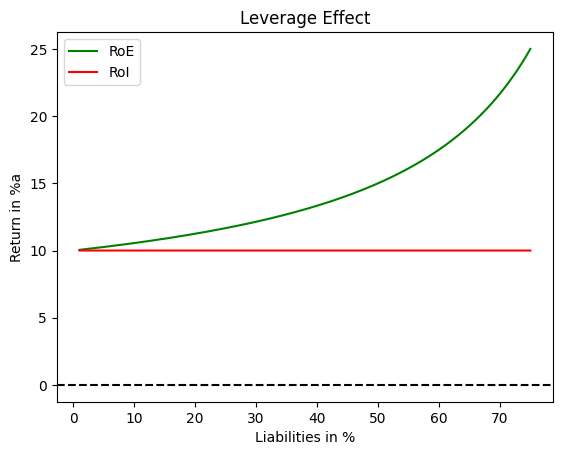

In [ ]:
#| label: fig-base-scenario
#| fig-cap: |
#|   With a return on investment of 10% and an average interest
#|   rate of 5% the return on equity grows when equity is substituted 
#|   with liabilities.  

fig, ax = plt.subplots()

ax.plot(df['Liabilities'], df['RoE'], label='RoE', color='green')
ax.plot(df['Liabilities'], df['RoI'], label='RoI', color='red')
ax.axhline(y=0, linestyle='--', color='black')
ax.set_xlabel('Liabilities in %')
ax.set_ylabel('Return in %')
plt.title('Leverage Effect')
plt.legend()
plt.show()

This sounds too good to be true. Does this hold under all
circumstances? 

In the next code cell the data set will be examined when the average
interest rate is 15%.

In [50]:
df['EBIT'] = 10
df['RoI'] = df['EBIT'] / (df['Liabilities'] + df['Equity']) * 100
df['Interest Rate'] = 15
df['Profit'] = (df['EBIT'] - df['Liabilities'] * 
               (df['Interest Rate']/100))
df['RoE'] = df['Profit'] / df['Equity'] *100
df

,Liabilities,Equity,EBIT,RoI,Interest Rate,Profit,RoE
0,1.000000,99.000000,10,10.0,15,9.850000,9.949495
1,1.037019,98.962981,10,10.0,15,9.844447,9.947606
2,1.074037,98.925963,10,10.0,15,9.838894,9.945715
3,1.111056,98.888944,10,10.0,15,9.833342,9.943823
4,1.148074,98.851926,10,10.0,15,9.827789,9.941930
...,...,...,...,...,...,...,...
1995,74.851926,25.148074,10,10.0,15,-1.227789,-4.882238
1996,74.888944,25.111056,10,10.0,15,-1.233342,-4.911548
1997,74.925963,25.074037,10,10.0,15,-1.238894,-4.940945
1998,74.962981,25.037019,10,10.0,15,-1.244447,-4.970429


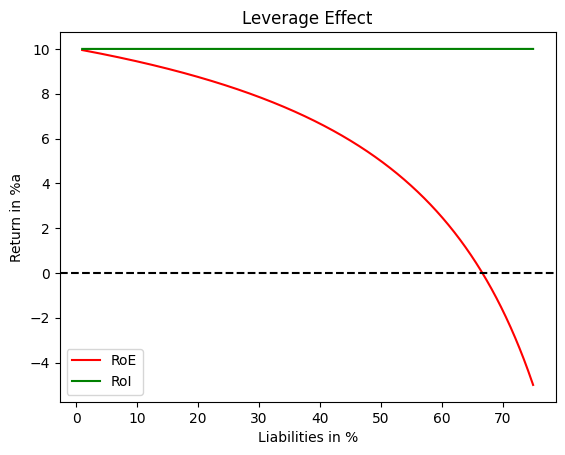

In [51]:
#| label: fig-high-interest-scenario
#| fig-cap: |
#|   With a return on investment of 10% and an average interest
#|   rate of 15% the return on equity declines when equity is
#|   substituted with liabilities.  

fig, ax = plt.subplots()

ax.plot(df['Liabilities'], df['RoE'], label='RoE', color='red')
ax.plot(df['Liabilities'], df['RoI'], label='RoI', color='green')
ax.axhline(y=0, linestyle='--', color='black')
ax.set_xlabel('Liabilities in %')
ax.set_ylabel('Return in %a')
plt.title('Leverage Effect')
plt.legend()
plt.show()

Before examining further examples, let's step back and consider the
coding aspect of the work done so far. It is useful to compare several
interest and RoI scenarios. To avoid repeating ourselves, we should use
a function to plot the different data sets. 

Therefore, the next code cell contains, the next code cell contains a Python function to plot different
RoI - interest rate combinations. 

In [75]:
def plot_roe(roi: float, interest_rate: float):
    if roi >= 1:
        roi = roi / 100
    if interest_rate >= 1:
        interest_rate = interest_rate / 100

    liabilities = np.linspace(1, 90, 2000)
    df = pd.DataFrame(liabilities, columns=['Liabilities'])
    df['Equity'] = 100 - df['Liabilities']
    df['EBIT'] = 100*roi
    df['Profit'] = df['EBIT'] - df['Liabilities'] * interest_rate
    df['RoE'] = df['Profit'] / df['Equity'] * 100
    df['RoI'] = roi * 100

    fig, ax = plt.subplots()
    ax.plot(df['Liabilities'], df['RoE'], label=f'RoE ({round(interest_rate*100, 2)}%)', color = 'red')
    ax.plot(df['Liabilities'], df['RoI'], label=f'RoI ({round(roi*100, 2)}%)', color = 'blue')
    ax.axhline(y=0, linestyle='--', color='black')
    ax.set_ylabel('Return (in %)')
    ax.set_xlabel('Liabilities (in %)')
    ax.set_title('Leverage Effect')
    plt.legend()
    plt.show()

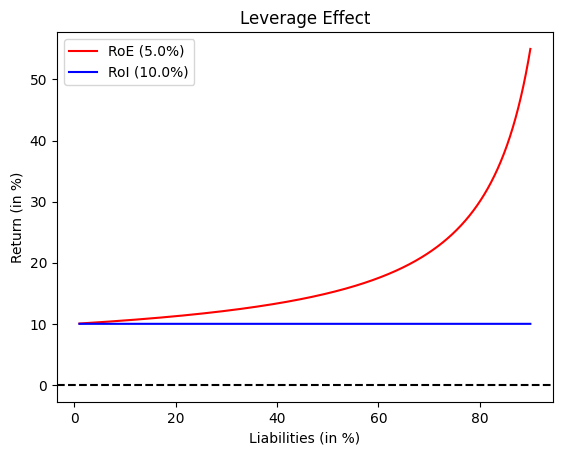

In [69]:
plot_roe(10, 5)

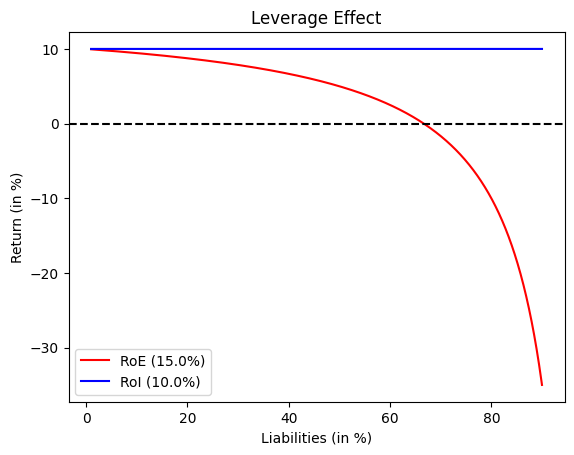

In [70]:
plot_roe(10, 15)

We could even plot range of interest rates.

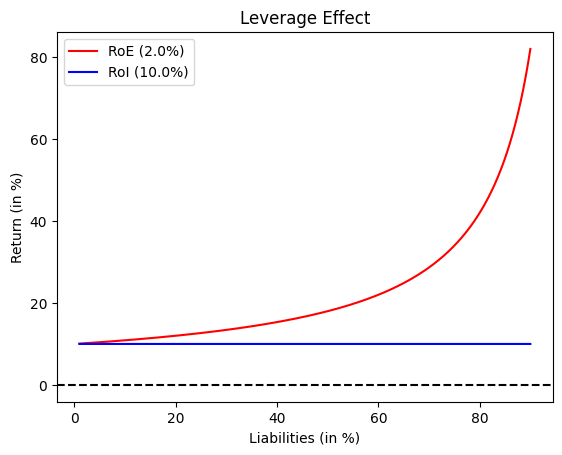

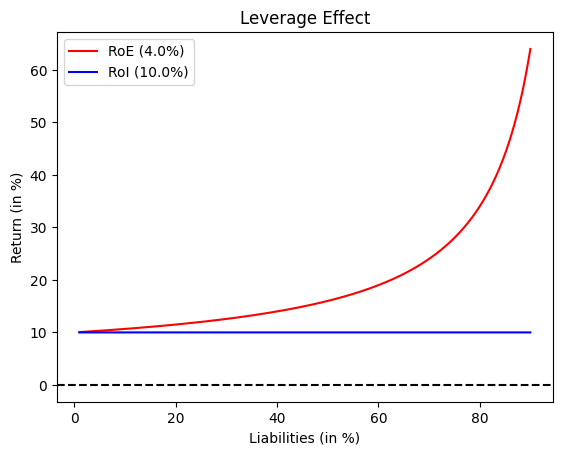

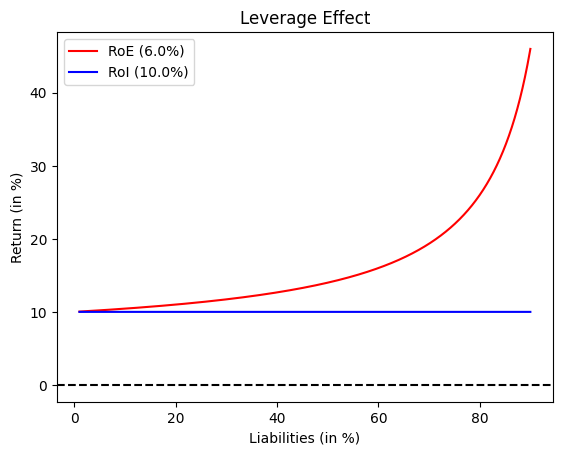

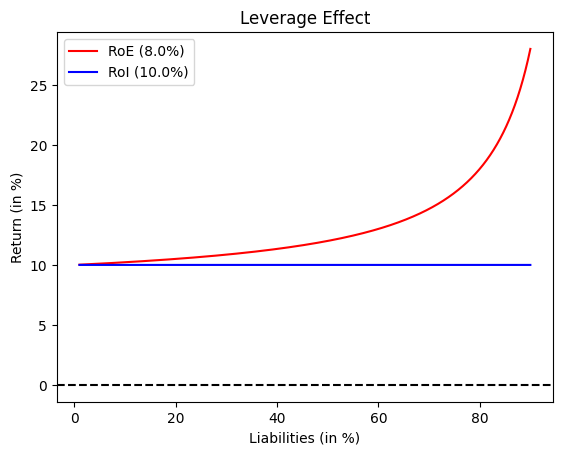

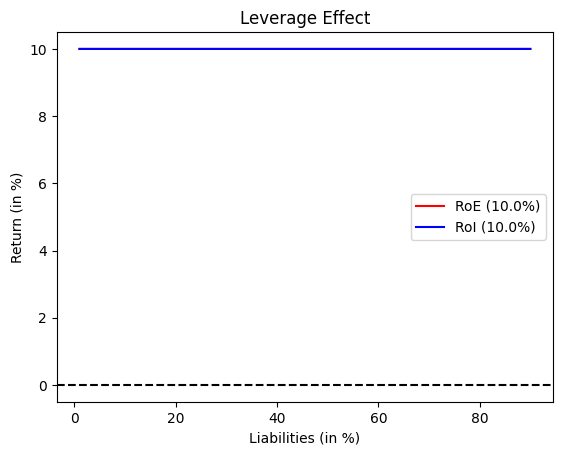

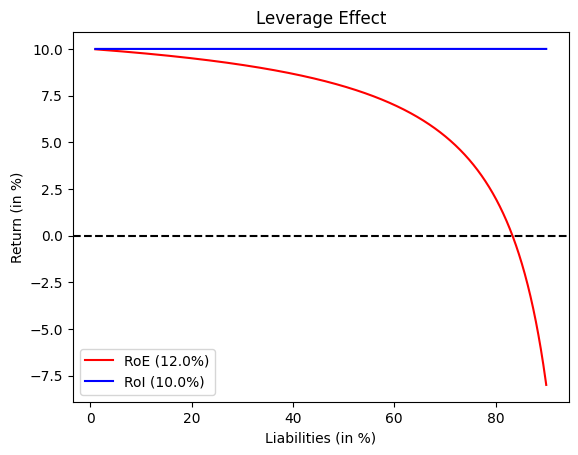

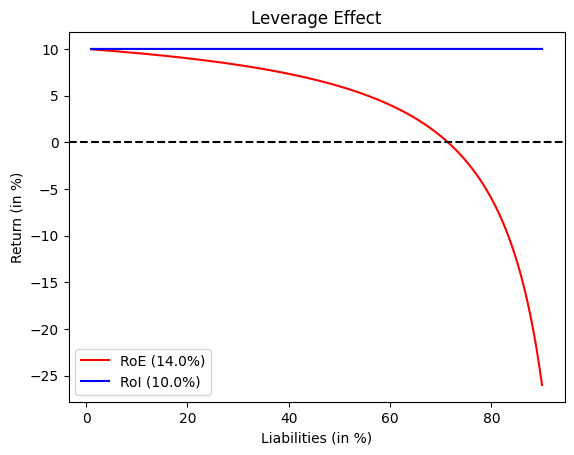

In [71]:
interest_rates = [i for i in range(2,16,2)]

for i in interest_rates:
    plot_roe(10, i)

The examination of our plots leads to the following observation: 

You can increase the RoE by substituting equity with liabilities as long as the interest rate for the liabilities is lower than the RoI.

This observation can be translated in **one** Formula:

$$
r = i + \frac{\text{Liabilities}}{\text{Equity}}(i- k)
$$

where

* $r$ is RoE
* $i$ is RoI
* $k$ is the average interest rate for the liabilities

To show that this is the same as above lets use this formula to plot the
same data set once again:

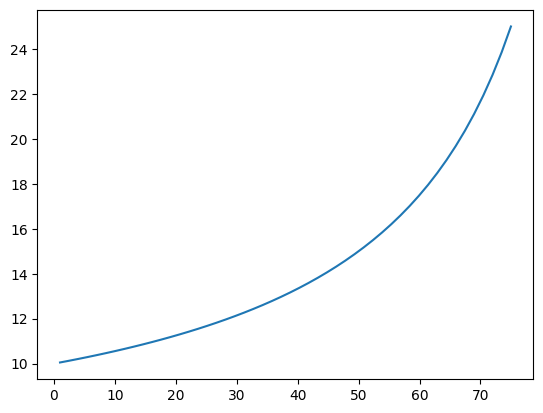

In [74]:
liabilities = np.linspace(1, 75)
equity = 100 - liabilities
fig, ax = plt.subplots()
ax.plot(liabilities, (10+(liabilities/equity)*(10 - 5)))
plt.show()